# QM640 Food Price Affordability AI
## Notebook 09 — Stakeholder Decision-Loss and Scenario Analysis

**RQ4:** How effectively can the proposed early-warning framework support
household budgeting, retail inventory, enterprise procurement, and
policy-monitoring decisions under alternative supply and price scenarios?

The notebook uses explicit, auditable loss matrices. Retrospective decision
tests and forward what-if scenarios are kept separate.


## 1. Setup and verified upstream artifacts


In [1]:
from pathlib import Path
import json, os, warnings
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)

try:
    import google.colab  # noqa
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    OUTPUT_ROOT = Path("/content/drive/MyDrive/QM640_Food_Affordability")
else:
    root = Path.cwd().resolve()
    if root.name == "notebooks": root = root.parent
    OUTPUT_ROOT = Path(os.environ.get("QM640_OUTPUT_ROOT", str(root)))

REPORT_OUTPUT = OUTPUT_ROOT / "reports" / "notebook_outputs"
FIGURES = REPORT_OUTPUT / "figures"
REPORT_OUTPUT.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)
SKIP_PLOTS = os.environ.get("QM640_SKIP_PLOTS", "0") == "1"

from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
if not SKIP_PLOTS:
    import matplotlib.pyplot as plt
    import seaborn as sns
    sns.set_theme(style="whitegrid")

forecast_predictions = pd.read_csv(
    REPORT_OUTPUT / "05_panel_rolling_predictions.csv.gz", parse_dates=["origin"]
)
forecast_metrics = pd.read_csv(REPORT_OUTPUT / "05_panel_model_metrics.csv")
shock_predictions = pd.read_csv(
    REPORT_OUTPUT / "06_rolling_shock_predictions.csv.gz", parse_dates=["origin"]
)
hfasi = pd.read_csv(REPORT_OUTPUT / "08_hfasi_state_sector_decile_24m.csv.gz", parse_dates=["date"])
forward_risk = pd.read_csv(REPORT_OUTPUT / "06_forward_multihorizon_shock_risk.csv", parse_dates=["target_date"])
nb05 = json.loads((REPORT_OUTPUT / "05_execution_summary.json").read_text(encoding="utf-8"))
nb06 = json.loads((REPORT_OUTPUT / "06_execution_summary.json").read_text(encoding="utf-8"))
nb08 = json.loads((REPORT_OUTPUT / "08_execution_summary.json").read_text(encoding="utf-8"))


Mounted at /content/drive


## 2. Explicit stakeholder loss assumptions


In [2]:
# Loss units are relative and stakeholder-specific; they are not rupee estimates.
STAKEHOLDERS = {
    "Household budgeting": {
        "event_type": "continuous", "adverse_threshold_pct": 5.0,
        "false_negative_cost": 4.0, "false_positive_cost": 1.0, "true_positive_action_cost": 0.25,
    },
    "Retail inventory": {
        "event_type": "continuous", "adverse_threshold_pct": 10.0,
        "false_negative_cost": 6.0, "false_positive_cost": 1.5, "true_positive_action_cost": 0.50,
    },
    "Enterprise procurement": {
        "event_type": "shock", "probability_cutoff": 0.30,
        "false_negative_cost": 8.0, "false_positive_cost": 2.0, "true_positive_action_cost": 0.75,
    },
    "Policy monitoring": {
        "event_type": "shock", "probability_cutoff": 0.25,
        "false_negative_cost": 10.0, "false_positive_cost": 3.0, "true_positive_action_cost": 1.00,
    },
}
assumption_table = pd.DataFrame([
    {"stakeholder": name, **values} for name, values in STAKEHOLDERS.items()
])
assumption_table.to_csv(REPORT_OUTPUT / "09_decision_loss_assumptions.csv", index=False)
print(assumption_table.to_string(index=False))

def decision_loss(actual_event, warning, fn_cost, fp_cost, tp_cost):
    actual_event = np.asarray(actual_event, dtype=int)
    warning = np.asarray(warning, dtype=int)
    return np.select(
        [
            (actual_event == 1) & (warning == 0),
            (actual_event == 0) & (warning == 1),
            (actual_event == 1) & (warning == 1),
        ],
        [fn_cost, fp_cost, tp_cost],
        default=0.0,
    )


           stakeholder event_type  adverse_threshold_pct  false_negative_cost  false_positive_cost  true_positive_action_cost  probability_cutoff
   Household budgeting continuous                    5.0                  4.0                  1.0                       0.25                 NaN
      Retail inventory continuous                   10.0                  6.0                  1.5                       0.50                 NaN
Enterprise procurement      shock                    NaN                  8.0                  2.0                       0.75                0.30
     Policy monitoring      shock                    NaN                 10.0                  3.0                       1.00                0.25


## 3. Retrospective paired decision-loss evaluation


In [3]:
evaluation_rows = []
loss_detail = []

for stakeholder, settings in STAKEHOLDERS.items():
    if settings["event_type"] == "continuous":
        parts = []
        for horizon in [1, 2, 3]:
            selected_model = nb05["selected_models_by_horizon"][f"{horizon}_month"]
            hm = forecast_metrics.loc[forecast_metrics["horizon_months"].eq(horizon)]
            baseline_model = (
                hm.loc[hm["model"].isin(["zero_change", "seasonal_change"])]
                .sort_values("rmse").iloc[0]["model"]
            )
            keys = ["horizon_months", "origin", "region", "Commodity", "actual"]
            selected = forecast_predictions.loc[
                (forecast_predictions["horizon_months"] == horizon)
                & (forecast_predictions["model"] == selected_model),
                keys + ["forecast"],
            ].rename(columns={"forecast": "model_signal"})
            baseline = forecast_predictions.loc[
                (forecast_predictions["horizon_months"] == horizon)
                & (forecast_predictions["model"] == baseline_model),
                keys[:-1] + ["forecast"],
            ].rename(columns={"forecast": "baseline_signal"})
            parts.append(selected.merge(
                baseline, on=["horizon_months", "origin", "region", "Commodity"], validate="one_to_one"
            ))
        frame = pd.concat(parts, ignore_index=True)
        event = frame["actual"].ge(settings["adverse_threshold_pct"]).astype(int)
        model_warning = frame["model_signal"].ge(settings["adverse_threshold_pct"]).astype(int)
        baseline_warning = frame["baseline_signal"].ge(settings["adverse_threshold_pct"]).astype(int)
    else:
        parts = []
        for horizon in [1, 2, 3]:
            selected_model = nb06["selected_models"][f"{horizon}_month"]
            selected = shock_predictions.loc[
                (shock_predictions["horizon_months"] == horizon)
                & (shock_predictions["model"] == selected_model)
            ].copy()
            baseline = shock_predictions.loc[
                (shock_predictions["horizon_months"] == horizon)
                & (shock_predictions["model"] == "persistence"),
                ["horizon_months", "origin", "region", "Commodity", "probability"],
            ].rename(columns={"probability": "baseline_probability"})
            parts.append(selected.merge(
                baseline, on=["horizon_months", "origin", "region", "Commodity"], validate="one_to_one"
            ))
        frame = pd.concat(parts, ignore_index=True)
        event = frame["actual_shock"].astype(int)
        model_warning = frame["probability"].ge(settings["probability_cutoff"]).astype(int)
        baseline_warning = frame["baseline_probability"].ge(settings["probability_cutoff"]).astype(int)

    model_loss = decision_loss(
        event, model_warning, settings["false_negative_cost"],
        settings["false_positive_cost"], settings["true_positive_action_cost"]
    )
    baseline_loss = decision_loss(
        event, baseline_warning, settings["false_negative_cost"],
        settings["false_positive_cost"], settings["true_positive_action_cost"]
    )
    no_warning_loss = decision_loss(
        event, np.zeros(len(event)), settings["false_negative_cost"],
        settings["false_positive_cost"], settings["true_positive_action_cost"]
    )
    try:
        statistic, p_value = wilcoxon(model_loss, baseline_loss, alternative="less", zero_method="zsplit")
    except ValueError:
        statistic, p_value = np.nan, 1.0

    rng = np.random.default_rng(640)
    differences = baseline_loss - model_loss
    boot = [
        differences[rng.integers(0, len(differences), len(differences))].mean()
        for _ in range(2000)
    ]
    ci = np.quantile(boot, [0.025, 0.975])
    evaluation_rows.append({
        "stakeholder": stakeholder, "observations": int(len(event)),
        "event_rate": float(event.mean()),
        "model_mean_loss": float(model_loss.mean()),
        "baseline_mean_loss": float(baseline_loss.mean()),
        "no_warning_mean_loss": float(no_warning_loss.mean()),
        "loss_reduction_vs_baseline_pct": (
            float((baseline_loss.mean() - model_loss.mean()) / baseline_loss.mean() * 100)
            if baseline_loss.mean() else np.nan
        ),
        "mean_loss_gain": float(differences.mean()),
        "bootstrap_gain_ci_lower": float(ci[0]),
        "bootstrap_gain_ci_upper": float(ci[1]),
        "one_sided_wilcoxon_p": float(p_value),
    })
    for idx in range(len(event)):
        loss_detail.append({
            "stakeholder": stakeholder, "actual_event": int(event.iloc[idx] if hasattr(event, "iloc") else event[idx]),
            "model_warning": int(model_warning.iloc[idx] if hasattr(model_warning, "iloc") else model_warning[idx]),
            "baseline_warning": int(baseline_warning.iloc[idx] if hasattr(baseline_warning, "iloc") else baseline_warning[idx]),
            "model_loss": float(model_loss[idx]), "baseline_loss": float(baseline_loss[idx]),
        })

decision_results = pd.DataFrame(evaluation_rows)
decision_results["p_value_holm"] = multipletests(
    decision_results["one_sided_wilcoxon_p"], alpha=0.05, method="holm"
)[1]
decision_results["decision_h0_4"] = np.where(
    (decision_results["p_value_holm"] < 0.05)
    & (decision_results["mean_loss_gain"] > 0)
    & (decision_results["bootstrap_gain_ci_lower"] > 0),
    "reject_H0_4_loss_reduced",
    "fail_to_reject_H0_4",
)
decision_results.to_csv(REPORT_OUTPUT / "09_retrospective_decision_loss.csv", index=False)
pd.DataFrame(loss_detail).to_csv(REPORT_OUTPUT / "09_decision_loss_detail.csv.gz", index=False, compression="gzip")
print(decision_results.round(5).to_string(index=False))


           stakeholder  observations  event_rate  model_mean_loss  baseline_mean_loss  no_warning_mean_loss  loss_reduction_vs_baseline_pct  mean_loss_gain  bootstrap_gain_ci_lower  bootstrap_gain_ci_upper  one_sided_wilcoxon_p  p_value_holm            decision_h0_4
   Household budgeting          3135     0.29187          0.60263             1.16746               1.16746                        48.38115         0.56483                  0.50852                  0.62496               0.00000       0.00000 reject_H0_4_loss_reduced
      Retail inventory          3135     0.22137          0.72105             1.32823               1.32823                        45.71326         0.60718                  0.53700                  0.68230               0.00001       0.00003 reject_H0_4_loss_reduced
Enterprise procurement          3135     0.06348          1.21188             0.57065               0.50781                      -112.36724        -0.64123                 -0.71882                 -0

## 4. Alternative supply and price scenarios


In [4]:
SCENARIOS = pd.DataFrame([
    ["Favorable supply", -2.0, 0.70],
    ["Baseline", 0.0, 1.00],
    ["Moderate stress", 3.0, 1.50],
    ["Severe stress", 6.0, 3.00],
], columns=["scenario", "food_cost_overlay_pp", "shock_probability_multiplier"])

baseline_hfasi = hfasi.loc[hfasi["purchasing_power_scenario"].eq("Baseline (4%)")].copy()
baseline_probability = float(forward_risk["shock_probability"].max())
scenario_rows = []
for row in SCENARIOS.itertuples():
    scenario_hfasi = baseline_hfasi["hfasi"] + (
        baseline_hfasi["weighted_food_expenditure_share"] * row.food_cost_overlay_pp
    )
    probability = min(1.0, baseline_probability * row.shock_probability_multiplier)
    for sector, group in baseline_hfasi.assign(scenario_hfasi=scenario_hfasi).groupby("sector"):
        maximum_hfasi = float(group["scenario_hfasi"].max())
        mean_hfasi = float(np.average(group["scenario_hfasi"], weights=group["sum_survey_weight"]))
        scenario_rows.append({
            "scenario": row.scenario, "sector": sector,
            "food_cost_overlay_pp": row.food_cost_overlay_pp,
            "maximum_hfasi": maximum_hfasi, "mean_hfasi": mean_hfasi,
            "maximum_shock_probability": probability,
            "household_budget_signal": "Elevated" if maximum_hfasi >= 102 else ("Watch" if maximum_hfasi >= 100 else "Normal"),
            "retail_inventory_signal": "Alert" if maximum_hfasi >= 102 or probability >= 0.50 else ("Watch" if maximum_hfasi >= 101 or probability >= 0.25 else "Normal"),
            "procurement_signal": "Alert" if probability >= 0.50 else ("Watch" if probability >= 0.30 else "Normal"),
            "policy_monitoring_signal": "Alert" if maximum_hfasi >= 102 and probability >= 0.50 else ("Watch" if maximum_hfasi >= 100 or probability >= 0.25 else "Normal"),
            "scenario_warning": "controlled what-if assumption; not a forecast",
        })
scenario_results = pd.DataFrame(scenario_rows)
scenario_results.to_csv(REPORT_OUTPUT / "09_forward_stakeholder_scenarios.csv", index=False)
print(scenario_results.round(4).to_string(index=False))


        scenario sector  food_cost_overlay_pp  maximum_hfasi  mean_hfasi  maximum_shock_probability household_budget_signal retail_inventory_signal procurement_signal policy_monitoring_signal                              scenario_warning
Favorable supply  Rural                  -2.0        99.3301     98.1020                     0.5743                  Normal                   Alert              Alert                    Watch controlled what-if assumption; not a forecast
Favorable supply  Urban                  -2.0        99.6000     98.5124                     0.5743                  Normal                   Alert              Alert                    Watch controlled what-if assumption; not a forecast
        Baseline  Rural                   0.0        99.8648     99.2278                     0.8205                  Normal                   Alert              Alert                    Watch controlled what-if assumption; not a forecast
        Baseline  Urban                   0.0   

## 5. Decision figures


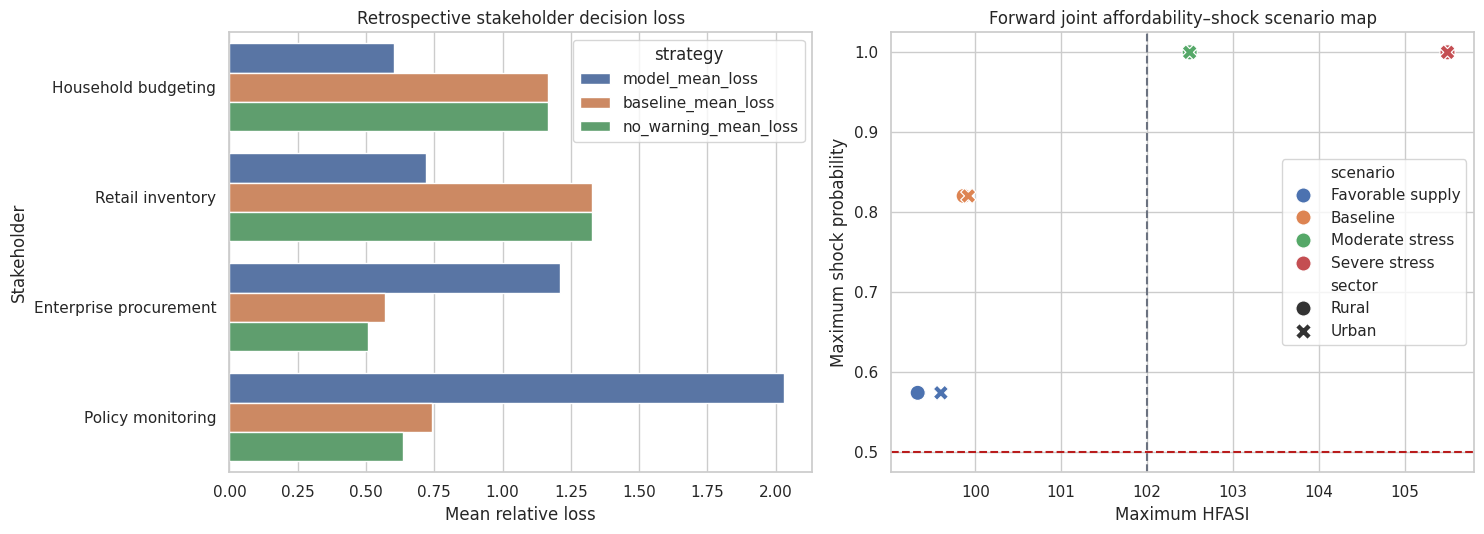

In [5]:
if not SKIP_PLOTS:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
    losses = decision_results.melt(
        id_vars="stakeholder",
        value_vars=["model_mean_loss", "baseline_mean_loss", "no_warning_mean_loss"],
        var_name="strategy", value_name="mean_loss"
    )
    sns.barplot(data=losses, x="mean_loss", y="stakeholder", hue="strategy", ax=axes[0])
    axes[0].set(title="Retrospective stakeholder decision loss", xlabel="Mean relative loss", ylabel="Stakeholder")
    sns.scatterplot(
        data=scenario_results, x="maximum_hfasi", y="maximum_shock_probability",
        hue="scenario", style="sector", s=120, ax=axes[1]
    )
    axes[1].axvline(102, linestyle="--", color="#6b7280")
    axes[1].axhline(0.50, linestyle="--", color="#b91c1c")
    axes[1].set(title="Forward joint affordability–shock scenario map", xlabel="Maximum HFASI", ylabel="Maximum shock probability")
    fig.tight_layout()
    fig.savefig(FIGURES / "09_aligned_decision_scenarios.png", bbox_inches="tight")
    plt.show()


## 6. Execution summary


In [6]:
overall_rejections = int(decision_results["decision_h0_4"].eq("reject_H0_4_loss_reduced").sum())
summary = {
    "notebook": "09_decision_scenario_analysis_synopsis_aligned",
    "status": "completed",
    "research_question_preserved": True,
    "stakeholders": list(STAKEHOLDERS),
    "retrospective_observations": {
        row.stakeholder: int(row.observations) for row in decision_results.itertuples()
    },
    "loss_reduction_pct": {
        row.stakeholder: (
            None if pd.isna(row.loss_reduction_vs_baseline_pct)
            else float(row.loss_reduction_vs_baseline_pct)
        ) for row in decision_results.itertuples()
    },
    "rq4_decisions": {
        row.stakeholder: row.decision_h0_4 for row in decision_results.itertuples()
    },
    "stakeholders_rejecting_h0_4": overall_rejections,
    "overall_rq4_conclusion": (
        "partial_support_model_warnings_reduce_loss_for_one_or_more_stakeholders"
        if overall_rejections > 0 else
        "insufficient_evidence_model_warnings_reduce_decision_loss"
    ),
    "scenarios": SCENARIOS["scenario"].tolist(),
    "highest_scenario_hfasi": float(scenario_results["maximum_hfasi"].max()),
    "highest_scenario_shock_probability": float(scenario_results["maximum_shock_probability"].max()),
    "scenario_interpretation": "Controlled what-if stress tests; not forecasts or causal effects.",
    "output_root": str(OUTPUT_ROOT),
}
SUMMARY_FILE = REPORT_OUTPUT / "09_execution_summary.json"
SUMMARY_FILE.write_text(json.dumps(summary, indent=2), encoding="utf-8")
expected = [
    REPORT_OUTPUT / "09_decision_loss_assumptions.csv",
    REPORT_OUTPUT / "09_retrospective_decision_loss.csv",
    REPORT_OUTPUT / "09_decision_loss_detail.csv.gz",
    REPORT_OUTPUT / "09_forward_stakeholder_scenarios.csv",
    SUMMARY_FILE,
]
if not SKIP_PLOTS: expected.append(FIGURES / "09_aligned_decision_scenarios.png")
missing = [str(p) for p in expected if not p.exists()]
if missing: raise FileNotFoundError("\n".join(missing))
print("=" * 76)
print("NOTEBOOK 09 ALIGNED EXECUTION SUMMARY — PLEASE SHARE THIS OUTPUT")
print("=" * 76)
print(json.dumps(summary, indent=2))
print(f"\nVerified artifacts: {len(expected)}")


NOTEBOOK 09 ALIGNED EXECUTION SUMMARY — PLEASE SHARE THIS OUTPUT
{
  "notebook": "09_decision_scenario_analysis_synopsis_aligned",
  "status": "completed",
  "research_question_preserved": true,
  "stakeholders": [
    "Household budgeting",
    "Retail inventory",
    "Enterprise procurement",
    "Policy monitoring"
  ],
  "retrospective_observations": {
    "Household budgeting": 3135,
    "Retail inventory": 3135,
    "Enterprise procurement": 3135,
    "Policy monitoring": 3135
  },
  "loss_reduction_pct": {
    "Household budgeting": 48.38114754098361,
    "Retail inventory": 45.71325648414985,
    "Enterprise procurement": -112.36724427054222,
    "Policy monitoring": -174.21437795953508
  },
  "rq4_decisions": {
    "Household budgeting": "reject_H0_4_loss_reduced",
    "Retail inventory": "reject_H0_4_loss_reduced",
    "Enterprise procurement": "fail_to_reject_H0_4",
    "Policy monitoring": "fail_to_reject_H0_4"
  },
  "stakeholders_rejecting_h0_4": 2,
  "overall_rq4_conclus

## Notebook 09 conclusion

Retrospective decision-loss tests provide the empirical RQ4 evidence. Forward
scenario signals demonstrate how the framework could be used, but their
overlays and probability multipliers are controlled assumptions—not predicted
effects. Loss weights are transparent relative utilities and should be replaced
with stakeholder-calibrated rupee costs before operational deployment.
